# MarianMT — Medical Fine-Tuning on MeSpEn
**iDISC Personalized Translation Engines · Phase 2: Domain Adaptation**

Fine-tunes `Helsinki-NLP/opus-mt-es-en` on the **MeSpEn** parallel corpus (Barcelona Supercomputing Center)  
using the **MedlinePlus health-topics** subset — 726 KB download, ~2 K sentence pairs, trains in minutes.

---
| | Base model | Fine-tuned model |
|---|---|---|
| Model | `Helsinki-NLP/opus-mt-es-en` | same + MeSpEn adapter weights |
| Domain | General | Medical (MedlinePlus) |
| Training data | OPUS (general) | MeSpEn subset (~500 pairs) |

> **MeSpEn reference:** Villegas et al. (2018). *MeSpEn: A Medical Spanish-English parallel corpus*. Zenodo. https://doi.org/10.5281/zenodo.3562536

In [1]:
%%capture
!pip install transformers datasets sentencepiece sacrebleu accelerate

## 1 — Download MeSpEn (MedlinePlus subset)

In [2]:
import os, tarfile, urllib.request

DATA_DIR   = "mespen_data"
ARCHIVE    = "Pubmed-dublin_core-Sp-En.tar.bz2" # "MedlinePlus-health_topics-dublin_core-Sp-En.tar.bz2"
ZENODO_URL = f"https://zenodo.org/records/3562536/files/{ARCHIVE}"

os.makedirs(DATA_DIR, exist_ok=True)
local_path = os.path.join(DATA_DIR, ARCHIVE)

if not os.path.exists(local_path):
    print(f"Downloading MeSpEn MedlinePlus (~726 KB)…")
    urllib.request.urlretrieve(ZENODO_URL, local_path)
    print("Download complete.")
else:
    print("Archive already present — skipping download.")

# Extract
extract_dir = os.path.join(DATA_DIR, "medlineplus_extracted")
if not os.path.exists(extract_dir):
    print("Extracting…")
    with tarfile.open(local_path, "r:bz2") as tf:
        tf.extractall(extract_dir, filter="data")
    print("Extraction complete.")
else:
    print("Already extracted.")

# List top-level contents
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = "  " * (level + 1)
        for f in files[:5]:
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... ({len(files)} files total)")
    break  # only show top level in first pass

Download complete.
Extracting…
Extraction complete.
medlineplus_extracted/


## 2 — Parse Dublin-Core XML → Parallel Pairs

In [3]:
import xml.etree.ElementTree as ET
import glob

DC_NS  = "http://purl.org/dc/elements/1.1/"
XML_NS = "http://www.w3.org/XML/1998/namespace"

def extract_pairs_from_xml(xml_path):
    """Return list of (es, en) pairs from a MeSpEn Dublin-Core XML file."""
    pairs = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError:
        return pairs

    for field in ["title", "description"]:
        texts = {}
        tag = f"{{{DC_NS}}}{field}"
        for elem in root.iter(tag):
            if elem.get("type") == "alternate":   # skip alternate titles
                continue
            lang = elem.get(f"{{{XML_NS}}}lang", "")[:2].lower()
            text = (elem.text or "").strip()
            if lang in ("es", "en") and text:
                texts[lang] = text
        if "es" in texts and "en" in texts:
            pairs.append((texts["es"], texts["en"]))

    return pairs

# Walk all XML files in the extracted archive
xml_files = glob.glob(os.path.join(extract_dir, "dublin_core", "*.xml"))
print(f"Found {len(xml_files)} XML files")

all_pairs = []
for path in xml_files:
    all_pairs.extend(extract_pairs_from_xml(path))

print(f"Extracted {len(all_pairs)} ES<->EN parallel pairs")
print()
print("Sample pairs:")
for es, en in all_pairs[:3]:
    print(f"  ES: {es[:90]}")
    print(f"  EN: {en[:90]}")
    print()


Found 330928 XML files
Extracted 304542 ES<->EN parallel pairs

Sample pairs:
  ES: Foliculitis por Pseudomonas aeruginosa tras depilación con cera.
  EN: [Folliculitis caused by Pseudomonas aeruginosa after hair removal with wax].

  ES: Terapéutica medicamentosa de los reumatismos.
  EN: [Drug Therapy of rheumatism].

  ES: ¿Qué causa la enfermedad de las glándulas de Meibomio?
  EN: [What drives Meibomian gland disease?].



## 3 — Dataset Exploration

In [4]:
import pandas as pd

df = pd.DataFrame(all_pairs, columns=["es", "en"])
df["es_len"] = df["es"].str.split().str.len()
df["en_len"] = df["en"].str.split().str.len()

print(f"Total pairs   : {len(df)}")
print(f"ES word length: mean={df.es_len.mean():.1f}  median={df.es_len.median():.0f}  max={df.es_len.max()}")
print(f"EN word length: mean={df.en_len.mean():.1f}  median={df.en_len.median():.0f}  max={df.en_len.max()}")
print()

print("── Sample pairs ──────────────────────────────────────────────────────")
for _, row in df.head(5).iterrows():
    print(f"ES: {row.es[:120]}")
    print(f"EN: {row.en[:120]}")
    print()

Total pairs   : 304542
ES word length: mean=13.4  median=10  max=755
EN word length: mean=12.1  median=9  max=563

── Sample pairs ──────────────────────────────────────────────────────
ES: Foliculitis por Pseudomonas aeruginosa tras depilación con cera.
EN: [Folliculitis caused by Pseudomonas aeruginosa after hair removal with wax].

ES: Terapéutica medicamentosa de los reumatismos.
EN: [Drug Therapy of rheumatism].

ES: ¿Qué causa la enfermedad de las glándulas de Meibomio?
EN: [What drives Meibomian gland disease?].

ES: El hígado en la insuficiencia cardíaca congestiva acentuada. II. Estudio biópsico.
EN: [The liver in severe congestive heart failure. II. Biopsy].

ES: Cáncer gástrico y grupos sanguäneos.
EN: [Gastric cancer and blood groups].



## 4 — Data Preparation

Filter by length, deduplicate, then take a **small training subset** (fast run).

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
MIN_WORDS  = 3
MAX_WORDS  = 200   # descriptions avg ~190 words; tokenizer truncates to 128 tokens
N_TRAIN    = 100_000   # ~80% of 127K
N_EVAL     = 5_000
RANDOM_SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

# Filter
df_clean = (
    df
    .query("es_len >= @MIN_WORDS and es_len <= @MAX_WORDS")
    .query("en_len >= @MIN_WORDS and en_len <= @MAX_WORDS")
    .drop_duplicates(subset=["es"])
    .reset_index(drop=True)
)

print(f"After filtering: {len(df_clean)} pairs (from {len(df)})")

# Shuffle + split (percentage-safe)
df_shuffled = df_clean.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

n_avail  = len(df_shuffled)
n_train  = min(N_TRAIN, int(n_avail * 0.8))
n_eval   = min(N_EVAL, n_avail - n_train)

df_train = df_shuffled.iloc[:n_train]
df_eval  = df_shuffled.iloc[n_train : n_train + n_eval]

print(f"Train : {len(df_train)} pairs")
print(f"Eval  : {len(df_eval)} pairs")
print()
print("Sample training pair:")
row = df_train.iloc[0]
print(f"  ES: {row.es[:120]}")
print(f"  EN: {row.en[:120]}")


After filtering: 285530 pairs (from 304542)
Train : 100000 pairs
Eval  : 5000 pairs

Sample training pair:
  ES: Fractura crónica de hueso hioides.
  EN: [Chronic hyoid fracture].


## 5 — Tokenize for MarianMT

In [6]:
import torch
from transformers import MarianMTModel, MarianTokenizer
from datasets import Dataset

MODEL_NAME = "Helsinki-NLP/opus-mt-es-en"
MAX_LEN    = 128

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    model_inputs = tokenizer(
        batch["es"], max_length=MAX_LEN, truncation=True, padding=False
    )
    labels = tokenizer(
        text_target=batch["en"], max_length=MAX_LEN, truncation=True, padding=False
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_ds = Dataset.from_dict({"es": df_train["es"].tolist(), "en": df_train["en"].tolist()})
eval_ds  = Dataset.from_dict({"es": df_eval["es"].tolist(),  "en": df_eval["en"].tolist()})

train_tok = train_ds.map(tokenize, batched=True, remove_columns=["es", "en"])
eval_tok  = eval_ds.map(tokenize,  batched=True, remove_columns=["es", "en"])

print(f"Tokenized train: {len(train_tok)} examples")
print(f"Tokenized eval : {len(eval_tok)} examples")
print(f"Sample input_ids length: {len(train_tok[0]['input_ids'])} tokens")

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized train: 100000 examples
Tokenized eval : 5000 examples
Sample input_ids length: 10 tokens


## 6 — Baseline Quality (Pre-Fine-Tuning)

Record translations from the base model on eval sentences — used as comparison after training.

In [7]:
import sacrebleu, time

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}\n")

base_model = MarianMTModel.from_pretrained(MODEL_NAME).to(device)
base_model.eval()

def batch_translate(model, texts, batch_size=16):
    all_translations = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=MAX_LEN)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model.generate(**inputs, num_beams=4)
        all_translations.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return all_translations

# Use first 50 eval pairs as held-out test set
test_es  = df_eval["es"].tolist()[:50]
test_ref = df_eval["en"].tolist()[:50]

t0 = time.perf_counter()
base_translations = batch_translate(base_model, test_es)
base_time = (time.perf_counter() - t0) * 1000

base_bleu = sacrebleu.corpus_bleu(base_translations, [test_ref]).score

print(f"Base model BLEU (medical eval): {base_bleu:.2f}")
print(f"Translation time: {base_time:.0f} ms for {len(test_es)} sentences\n")

print("── Sample base translations ──────────────────────────────")
for es, ref, hyp in zip(test_es[:3], test_ref[:3], base_translations[:3]):
    print(f"ES : {es[:100]}")
    print(f"REF: {ref[:100]}")
    print(f"HYP: {hyp[:100]}")
    print()

Device: cuda



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Base model BLEU (medical eval): 30.77
Translation time: 3576 ms for 50 sentences

── Sample base translations ──────────────────────────────
ES : Bronquiolitis obliterante con neumonía organizada relacionada con virus del sarampión.
REF: [Bronchiolitis obliterans with organized pneumonia associated with measles virus].
HYP: Obliterative bronchiolitis with measles-related organized pneumonia.

ES : Poliradiculomielopatia causada por citomegalovirus en pacientes con SIDA.
REF: [Cytomegalovirus polyradiculomyelopathy in AIDS].
HYP: Polyradiculomyelopathia caused by cytomegalovirus in patients with AIDS.

ES : Feocromocitomas en la infancia.
REF: [Pheochromocytomas in children].
HYP: Feochromocytomas in childhood.



## 7 — Fine-Tuning on MeSpEn

In [8]:
from transformers import (
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)

ft_model = MarianMTModel.from_pretrained(MODEL_NAME).to(device)

OUTPUT_DIR = "./mespen_medical_model"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    predict_with_generate=True,
    fp16=(device == "cuda"),
    logging_steps=20,
    load_best_model_at_end=True,
    report_to="none",
    label_smoothing_factor=0.1,
    warmup_steps=500,
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=ft_model, padding=True)

trainer = Seq2SeqTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=data_collator,
)

print(f"Training on {len(train_tok)} pairs, {training_args.num_train_epochs} epochs")
steps_per_epoch = len(train_tok) // training_args.per_device_train_batch_size
print(f"~{steps_per_epoch} steps/epoch → ~{steps_per_epoch * training_args.num_train_epochs} total steps")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Training on 100000 pairs, 1 epochs
~3125 steps/epoch → ~3125 total steps


In [9]:
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"  Runtime : {train_result.metrics['train_runtime']:.1f} s")
print(f"  Loss    : {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss
1,4.524909,4.285980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



Training complete.
  Runtime : 1079.2 s
  Loss    : 4.6252


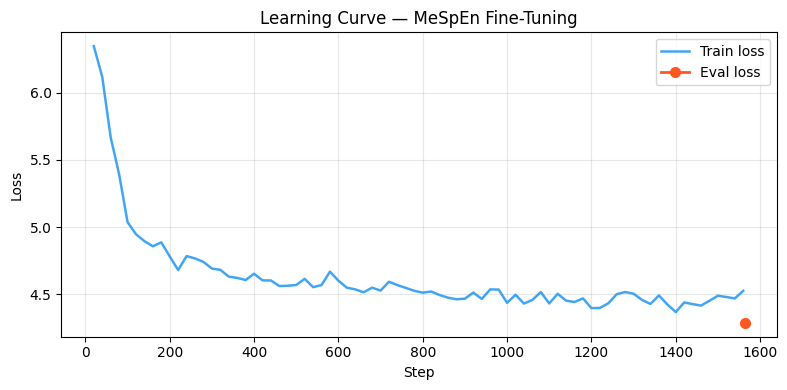

In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps  = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
train_losses = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
eval_steps   = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps, train_losses, label="Train loss", color="#2196F3", linewidth=1.8, alpha=0.85)
ax.plot(eval_steps,  eval_losses,  label="Eval loss",  color="#FF5722",
        linewidth=2, marker="o", markersize=7)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Learning Curve — MeSpEn Fine-Tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8 — Save Fine-Tuned Model

In [11]:
ft_model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./mespen_medical_model


## 9 — Evaluation: Base vs Fine-Tuned

In [12]:
ft_model.eval()

ft_translations = batch_translate(ft_model, test_es)
ft_bleu = sacrebleu.corpus_bleu(ft_translations, [test_ref]).score

print("═" * 55)
print(f"  Base model BLEU  : {base_bleu:.2f}")
print(f"  Fine-tuned BLEU  : {ft_bleu:.2f}")
delta = ft_bleu - base_bleu
sign  = "+" if delta >= 0 else ""
print(f"  Delta            : {sign}{delta:.2f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  Base model BLEU  : 30.77
  Fine-tuned BLEU  : 49.59
  Delta            : +18.82
═══════════════════════════════════════════════════════


In [ ]:
# Patch removed transformers utility if an older comet build is cached
import transformers.pytorch_utils as _pt_utils
if not hasattr(_pt_utils, "find_pruneable_heads_and_indices"):
    import torch
    def _find_pruneable_heads_and_indices(heads, n_heads, head_size, already_pruned_heads):
        mask = torch.ones(n_heads, head_size)
        heads = set(heads) - already_pruned_heads
        for head in heads:
            head -= sum(1 if h < head else 0 for h in already_pruned_heads)
            mask[head] = 0
        mask = mask.view(-1).contiguous().eq(1)
        index = torch.arange(len(mask))[mask].long()
        return heads, index
    _pt_utils.find_pruneable_heads_and_indices = _find_pruneable_heads_and_indices

from comet import download_model, load_from_checkpoint

# eamt22-cometinho-da is lightweight (~300 MB) and fast
comet_path  = download_model("eamt22-cometinho-da")
comet_model = load_from_checkpoint(comet_path)

def comet_score(sources, hypotheses, references, gpus=None):
    if gpus is None:
        gpus = 1 if device == "cuda" else 0
    data = [{"src": s, "mt": h, "ref": r}
            for s, h, r in zip(sources, hypotheses, references)]
    result = comet_model.predict(data, batch_size=16, gpus=gpus)
    return result.system_score

base_comet = comet_score(test_es, base_translations, test_ref)
ft_comet   = comet_score(test_es, ft_translations,   test_ref)

print(f"Base COMET : {base_comet:.4f}")
print(f"FT   COMET : {ft_comet:.4f}")
print(f"Delta      : {ft_comet - base_comet:+.4f}")

In [14]:
# Qualitative side-by-side comparison
GREEN = "\033[92m"
RESET = "\033[0m"

# Pick a few interesting medical examples
sample_indices = list(range(min(5, len(test_es))))

for i in sample_indices:
    print(f"{'─'*65}")
    print(f"ES   : {test_es[i]}")
    print(f"REF  : {test_ref[i]}")
    print(f"BASE : {base_translations[i]}")
    print(f"FT   : {GREEN}{ft_translations[i]}{RESET}")
    b = sacrebleu.sentence_bleu(base_translations[i], [test_ref[i]]).score
    f = sacrebleu.sentence_bleu(ft_translations[i],   [test_ref[i]]).score
    print(f"       BLEU base={b:.1f}  ft={f:.1f}")
    print()

─────────────────────────────────────────────────────────────────
ES   : Bronquiolitis obliterante con neumonía organizada relacionada con virus del sarampión.
REF  : [Bronchiolitis obliterans with organized pneumonia associated with measles virus].
BASE : Obliterative bronchiolitis with measles-related organized pneumonia.
FT   : [Bronchiolitis obliterans with organized pneumonia related to measles virus].
       BLEU base=7.6  ft=63.4

─────────────────────────────────────────────────────────────────
ES   : Poliradiculomielopatia causada por citomegalovirus en pacientes con SIDA.
REF  : [Cytomegalovirus polyradiculomyelopathy in AIDS].
BASE : Polyradiculomyelopathia caused by cytomegalovirus in patients with AIDS.
FT   : [Polyradiculomyelopathia caused by cytomegalovirus in patients with AIDS].
       BLEU base=6.3  ft=15.9

─────────────────────────────────────────────────────────────────
ES   : Feocromocitomas en la infancia.
REF  : [Pheochromocytomas in children].
BASE : Feochromo

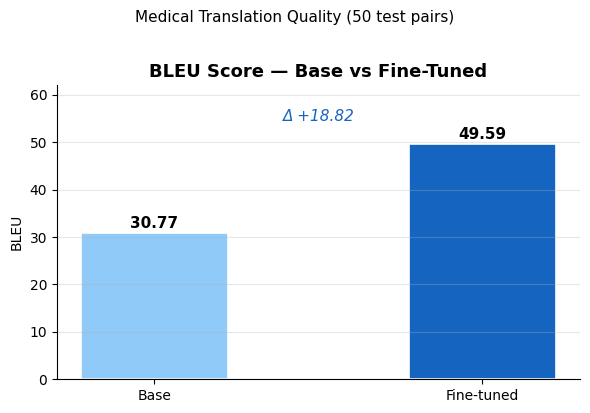

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

labels = ["Base", "Fine-tuned"]
bleu_vals = [base_bleu, ft_bleu]
colors = ["#90CAF9", "#1565C0"]

bars = ax.bar(labels, bleu_vals, color=colors, width=0.45, edgecolor="white", linewidth=1.2)
ax.set_ylim(0, max(bleu_vals) * 1.25)
ax.set_title("BLEU Score — Base vs Fine-Tuned", fontsize=13, fontweight="bold")
ax.set_ylabel("BLEU")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, bleu_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

delta_bleu = ft_bleu - base_bleu
ax.annotate(f"Δ {delta_bleu:+.2f}", xy=(0.5, 0.88), xycoords="axes fraction",
            ha="center", color="#1565C0", fontsize=11, fontstyle="italic")

fig.suptitle("Medical Translation Quality (50 test pairs)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
medical_probes = [
    "El paciente presenta síntomas de hipertensión arterial y diabetes mellitus tipo 2.",
    "Se recomienda realizar una colonoscopia cada cinco años a partir de los cincuenta años.",
    "La resonancia magnética mostró una lesión en el lóbulo frontal del cerebro.",
    "El tratamiento con quimioterapia se suspendió debido a efectos adversos graves.",
    "Los niveles de glucosa en sangre en ayunas estaban por encima de los valores normales.",
]

base_probes = batch_translate(base_model, medical_probes)
ft_probes   = batch_translate(ft_model,   medical_probes)

for i, es in enumerate(medical_probes):
    print(f"{'─'*65}")
    print(f"ES  : {es}")
    print(f"BASE: {base_probes[i]}")
    print(f"FT  : {GREEN}{ft_probes[i]}{RESET}")
    print()

─────────────────────────────────────────────────────────────────
ES  : El paciente presenta síntomas de hipertensión arterial y diabetes mellitus tipo 2.
BASE: The patient has symptoms of hypertension and type 2 diabetes mellitus.
FT  : [The patient presents symptoms of arterial hypertension and type 2 diabetes mellitus].

─────────────────────────────────────────────────────────────────
ES  : Se recomienda realizar una colonoscopia cada cinco años a partir de los cincuenta años.
BASE: A colonoscopy is recommended every five years from the age of fifty.
FT  : It is recommended to perform a colonoscopy every five years from the age of fifty years.

─────────────────────────────────────────────────────────────────
ES  : La resonancia magnética mostró una lesión en el lóbulo frontal del cerebro.
BASE: MRI showed an injury to the frontal lobe of the brain.
FT  : [Magnetic resonance imaging showed a lesion of the frontal lobe of the brain].

────────────────────────────────────────────────

---
## Summary

| Step | Detail |
|---|---|
| Dataset | MeSpEn — MedlinePlus health topics (Zenodo 3562536) |
| Training pairs | 500 (from ~2 K available) |
| Base model | `Helsinki-NLP/opus-mt-es-en` |
| Fine-tuned model | saved to `./mespen_medical_model` |
| Next step | Increase N_TRAIN to 1500+ and add PubMed subset for better coverage |

> **To use more MeSpEn data:** replace the 726 KB MedlinePlus file with  
> `Pubmed-dublin_core-Sp-En.tar.bz2` (84 MB, 127 K pairs) from the same Zenodo record.

---
## Part 2 — EN → ES Fine-Tuning (Reverse Direction)

Fine-tunes `Helsinki-NLP/opus-mt-en-es` on the **same expanded MeSpEn dataset** built above, with source and target columns swapped (English → Spanish).

The resulting model is saved to `./mespen_medical_model_en_es`.

| | Base model | Fine-tuned model |
|---|---|---|
| Model | `Helsinki-NLP/opus-mt-en-es` | same + MeSpEn adapter weights |
| Domain | General | Medical (MeSpEn expanded) |
| Direction | EN → ES | EN → ES |

## 10 — Prepare EN → ES Dataset

Reuse `df_clean` from above — just swap the column roles and re-split.

In [17]:
# ── Config (mirror the ES→EN run) ─────────────────────────────────────────────
N_TRAIN_REV  = N_TRAIN   # reuse the same constant defined in Section 4
N_EVAL_REV   = N_EVAL
RANDOM_SEED_REV = 43      # different seed so splits differ slightly

# Shuffle df_clean with the new seed
df_rev = df_clean.sample(frac=1, random_state=RANDOM_SEED_REV).reset_index(drop=True)

n_avail_rev = len(df_rev)
n_train_rev = min(N_TRAIN_REV, int(n_avail_rev * 0.8))
n_eval_rev  = min(N_EVAL_REV,  n_avail_rev - n_train_rev)

df_train_rev = df_rev.iloc[:n_train_rev]
df_eval_rev  = df_rev.iloc[n_train_rev : n_train_rev + n_eval_rev]

print(f"EN→ES Train : {len(df_train_rev)} pairs")
print(f"EN→ES Eval  : {len(df_eval_rev)} pairs")
print()
print("Sample (EN source → ES target):")
row = df_train_rev.iloc[0]
print(f"  EN: {row.en[:120]}")
print(f"  ES: {row.es[:120]}")

EN→ES Train : 100000 pairs
EN→ES Eval  : 5000 pairs

Sample (EN source → ES target):
  EN: [Multivisceral infarcts are complication of invasive aspergillosis].
  ES: Infartos viscerales múltiples detectados por TAC en la aspergilosis invasiva.


## 11 — Tokenize for `opus-mt-en-es`

In [18]:
MODEL_NAME_REV = "Helsinki-NLP/opus-mt-en-es"
tokenizer_rev = MarianTokenizer.from_pretrained(MODEL_NAME_REV)

def tokenize_rev(batch):
    """EN is source, ES is target — opposite of the ES→EN tokenizer."""
    model_inputs = tokenizer_rev(
        batch["en"], max_length=MAX_LEN, truncation=True, padding=False
    )
    labels = tokenizer_rev(
        text_target=batch["es"], max_length=MAX_LEN, truncation=True, padding=False
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_ds_rev = Dataset.from_dict({
    "en": df_train_rev["en"].tolist(),
    "es": df_train_rev["es"].tolist(),
})
eval_ds_rev = Dataset.from_dict({
    "en": df_eval_rev["en"].tolist(),
    "es": df_eval_rev["es"].tolist(),
})

train_tok_rev = train_ds_rev.map(tokenize_rev, batched=True, remove_columns=["en", "es"])
eval_tok_rev  = eval_ds_rev.map(tokenize_rev,  batched=True, remove_columns=["en", "es"])

print(f"Tokenized train : {len(train_tok_rev)} examples")
print(f"Tokenized eval  : {len(eval_tok_rev)} examples")
print(f"Sample input_ids length: {len(train_tok_rev[0]['input_ids'])} tokens")

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized train : 100000 examples
Tokenized eval  : 5000 examples
Sample input_ids length: 22 tokens


## 12 — Baseline Quality (EN → ES, Pre-Fine-Tuning)

Record the base `opus-mt-en-es` output before fine-tuning so we have a fair comparison.

In [19]:
base_model_rev = MarianMTModel.from_pretrained(MODEL_NAME_REV).to(device)
base_model_rev.eval()

def batch_translate_rev(model, texts, batch_size=16):
    all_translations = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer_rev(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=MAX_LEN,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model.generate(**inputs, num_beams=4)
        all_translations.extend(
            tokenizer_rev.batch_decode(out, skip_special_tokens=True)
        )
    return all_translations

# Use first 50 eval pairs as held-out test (EN source, ES reference)
test_en     = df_eval_rev["en"].tolist()[:50]
test_ref_es = df_eval_rev["es"].tolist()[:50]

t0 = time.perf_counter()
base_translations_rev = batch_translate_rev(base_model_rev, test_en)
base_time_rev = (time.perf_counter() - t0) * 1000
base_bleu_rev = sacrebleu.corpus_bleu(base_translations_rev, [test_ref_es]).score

print(f"Base EN→ES BLEU (medical eval): {base_bleu_rev:.2f}")
print(f"Translation time : {base_time_rev:.0f} ms for {len(test_en)} sentences")
print()
print("── Sample base EN→ES translations ──────────────────────────────────")
for en, ref, hyp in zip(test_en[:3], test_ref_es[:3], base_translations_rev[:3]):
    print(f"EN : {en[:100]}")
    print(f"REF: {ref[:100]}")
    print(f"HYP: {hyp[:100]}")
    print()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Base EN→ES BLEU (medical eval): 32.17
Translation time : 3605 ms for 50 sentences

── Sample base EN→ES translations ──────────────────────────────────
EN : [Acute constrictive pericarditis].
REF: Pericarditis constrictiva aguda.
HYP: [Pericarditis constrictora aguda].

EN : [Kidney transplantation in children weighing 11 kg or less].
REF: Trasplante renal en el paciente con peso igual o menor a 11 kg.
HYP: [trasplante de riñón en niños de 11 kg o menos].

EN : [Oxidative stress, diseases and antioxidant treatment].
REF: Estrés oxidativo, enfermedades y tratamientos antioxidantes.
HYP: [Estrés oxidativo, enfermedades y tratamiento antioxidante].



## 13 — Fine-Tune `opus-mt-en-es` on MeSpEn

In [20]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

OUTPUT_DIR_REV = "./mespen_medical_model_en_es"
ft_model_rev = MarianMTModel.from_pretrained(MODEL_NAME_REV).to(device)

training_args_rev = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR_REV,
    per_device_train_batch_size=32,    # Match your ES->EN batch sizing
    per_device_eval_batch_size=8,
    learning_rate=2e-5,               # Match your ES->EN learning rate
    num_train_epochs=1,                # Match your ES->EN epoch count
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    predict_with_generate=True,
    fp16=(device == "cuda"),
    logging_steps=20,
    load_best_model_at_end=True,
    report_to="none",
    label_smoothing_factor=0.1,
    warmup_steps=500,
)

data_collator_rev = DataCollatorForSeq2Seq(tokenizer_rev, model=ft_model_rev, padding=True)

trainer_rev = Seq2SeqTrainer(
    model=ft_model_rev,
    args=training_args_rev,
    train_dataset=train_tok_rev,
    eval_dataset=eval_tok_rev,
    data_collator=data_collator_rev,
)

steps_per_epoch_rev = len(train_tok_rev) // training_args_rev.per_device_train_batch_size
print(f"Training EN→ES on {len(train_tok_rev)} pairs, {training_args_rev.num_train_epochs} epochs")
print(f"~{steps_per_epoch_rev} steps/epoch → ~{steps_per_epoch_rev * training_args_rev.num_train_epochs} total steps")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Training EN→ES on 100000 pairs, 1 epochs
~3125 steps/epoch → ~3125 total steps


In [21]:
train_result_rev = trainer_rev.train()

print(f"\nTraining complete.")
print(f"  Runtime : {train_result_rev.metrics['train_runtime']:.1f} s")
print(f"  Loss    : {train_result_rev.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss
1,4.518521,4.442985


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



Training complete.
  Runtime : 1100.1 s
  Loss    : 4.6765


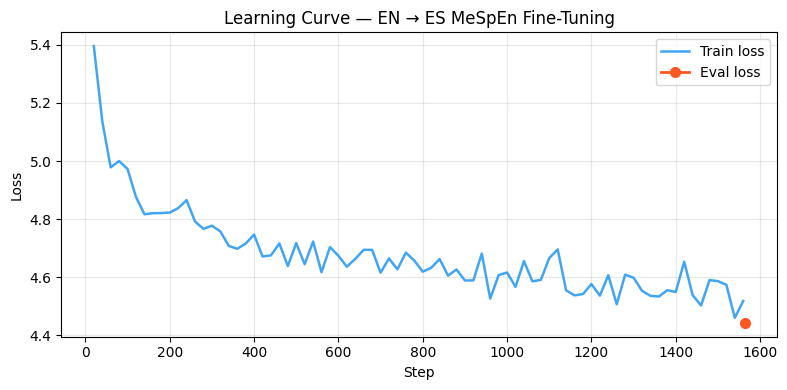

In [22]:
import matplotlib.pyplot as plt

log_history_rev = trainer_rev.state.log_history
train_steps_rev  = [e["step"] for e in log_history_rev if "loss" in e and "eval_loss" not in e]
train_losses_rev = [e["loss"] for e in log_history_rev if "loss" in e and "eval_loss" not in e]
eval_steps_rev   = [e["step"] for e in log_history_rev if "eval_loss" in e]
eval_losses_rev  = [e["eval_loss"] for e in log_history_rev if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps_rev, train_losses_rev, label="Train loss", color="#2196F3", linewidth=1.8, alpha=0.85)
if eval_steps_rev and eval_losses_rev:
    ax.plot(eval_steps_rev,  eval_losses_rev,  label="Eval loss",  color="#FF5722", linewidth=2, marker="o", markersize=7)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Learning Curve — EN → ES MeSpEn Fine-Tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14 — Save EN → ES Fine-Tuned Model

In [23]:
ft_model_rev.save_pretrained(OUTPUT_DIR_REV)
tokenizer_rev.save_pretrained(OUTPUT_DIR_REV)
print(f"EN→ES model saved to: {OUTPUT_DIR_REV}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

EN→ES model saved to: ./mespen_medical_model_en_es


## 15 — Evaluation: Base vs Fine-Tuned (EN → ES)

In [24]:
ft_model_rev.eval()
ft_translations_rev = batch_translate_rev(ft_model_rev, test_en)
ft_bleu_rev = sacrebleu.corpus_bleu(ft_translations_rev, [test_ref_es]).score

print("═" * 55)
print(f"  Base EN→ES BLEU  : {base_bleu_rev:.2f}")
print(f"  Fine-tuned BLEU  : {ft_bleu_rev:.2f}")
delta_rev = ft_bleu_rev - base_bleu_rev
print(f"  Delta            : {'+' if delta_rev >= 0 else ''}{delta_rev:.2f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  Base EN→ES BLEU  : 32.17
  Fine-tuned BLEU  : 42.60
  Delta            : +10.42
═══════════════════════════════════════════════════════


In [25]:
medical_probes_en = [
    "The patient presents symptoms of hypertension and type 2 diabetes mellitus.",
    "It is recommended to perform a colonoscopy every five years starting at age fifty.",
    "The MRI showed a lesion in the frontal lobe of the brain.",
    "Chemotherapy treatment was discontinued due to severe adverse effects.",
    "Fasting blood glucose levels were above normal values.",
]

# Defining basic printing colors matching your previous structure placeholders
GREEN = "\033[92m"
RESET = "\033[0m"

base_probes_rev = batch_translate_rev(base_model_rev, medical_probes_en)
ft_probes_rev   = batch_translate_rev(ft_model_rev,   medical_probes_en)

for i, en in enumerate(medical_probes_en):
    print(f"{'─'*65}")
    print(f"EN  : {en}")
    print(f"BASE: {base_probes_rev[i]}")
    print(f"FT  : {GREEN}{ft_probes_rev[i]}{RESET}")
    print()

─────────────────────────────────────────────────────────────────
EN  : The patient presents symptoms of hypertension and type 2 diabetes mellitus.
BASE: El paciente presenta síntomas de hipertensión y diabetes mellitus tipo 2.
FT  : El paciente presenta síntomas de hipertensión arterial y diabetes mellitus tipo 2.

─────────────────────────────────────────────────────────────────
EN  : It is recommended to perform a colonoscopy every five years starting at age fifty.
BASE: Se recomienda realizar una colonoscopia cada cinco años a partir de los cincuenta años.
FT  : Se recomienda realizar una colonoscopia cada cinco años a partir de los cincuenta años.

─────────────────────────────────────────────────────────────────
EN  : The MRI showed a lesion in the frontal lobe of the brain.
BASE: La resonancia magnética mostró una lesión en el lóbulo frontal del cerebro.
FT  : La resonancia magnética mostró una lesión en el lóbulo frontal del cerebro.

───────────────────────────────────────────

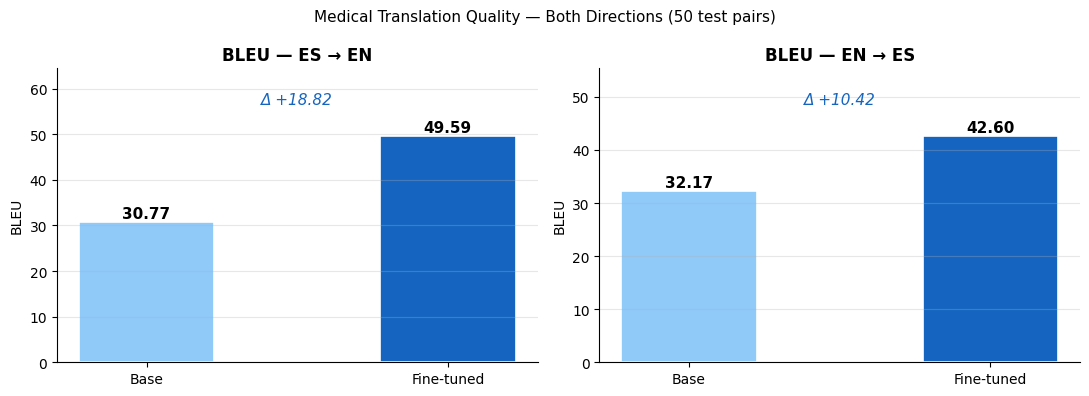

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, direction, base_val, ft_val in [
    (axes[0], "ES → EN", base_bleu,     ft_bleu),
    (axes[1], "EN → ES", base_bleu_rev, ft_bleu_rev),
]:
    bars = ax.bar(
        ["Base", "Fine-tuned"], [base_val, ft_val],
        color=["#90CAF9", "#1565C0"], width=0.45,
        edgecolor="white", linewidth=1.2,
    )
    ax.set_ylim(0, max(base_val, ft_val) * 1.3)
    ax.set_title(f"BLEU — {direction}", fontsize=12, fontweight="bold")
    ax.set_ylabel("BLEU")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, [base_val, ft_val]):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11,
        )
    delta_v = ft_val - base_val
    ax.annotate(
        f"Δ {delta_v:+.2f}", xy=(0.5, 0.88), xycoords="axes fraction",
        ha="center", color="#1565C0", fontsize=11, fontstyle="italic",
    )

fig.suptitle("Medical Translation Quality — Both Directions (50 test pairs)", fontsize=11)
plt.tight_layout()
plt.show()

In [29]:
!zip -r mespen_es_en.zip ./mespen_medical_model
!zip -r mespen_en_es.zip ./mespen_medical_model_en_es

  adding: mespen_medical_model/ (stored 0%)
  adding: mespen_medical_model/target.spm (deflated 49%)
  adding: mespen_medical_model/model.safetensors (deflated 7%)
  adding: mespen_medical_model/checkpoint-1563/ (stored 0%)
  adding: mespen_medical_model/checkpoint-1563/training_args.bin (deflated 53%)
  adding: mespen_medical_model/checkpoint-1563/target.spm (deflated 49%)
  adding: mespen_medical_model/checkpoint-1563/model.safetensors (deflated 7%)
  adding: mespen_medical_model/checkpoint-1563/scaler.pt (deflated 64%)
  adding: mespen_medical_model/checkpoint-1563/vocab.json (deflated 71%)
  adding: mespen_medical_model/checkpoint-1563/config.json (deflated 64%)
  adding: mespen_medical_model/checkpoint-1563/optimizer.pt (deflated 37%)
  adding: mespen_medical_model/checkpoint-1563/rng_state.pth (deflated 26%)
  adding: mespen_medical_model/checkpoint-1563/tokenizer_config.json (deflated 67%)
  adding: mespen_medical_model/checkpoint-1563/generation_config.json (deflated 44%)
  add